# Track A - Transfer-Safe SINDy Dynamics, LQR, and PPO Polish

This notebook keeps the original Track A goal, but makes the validation order explicit:

1. Define the MuJoCo geometry and reward in notebook variables.
2. Optionally validate that geometry against the real MuJoCo site and reward.
3. Collect local one-step state-action probes for SINDy.
4. Fit SINDy and score it on a fixed validation probe set.
5. Linearize the learned SINDy model around upright.
6. Compute an LQR controller from the learned SINDy linearization.
7. Evaluate that controller in real MuJoCo before trusting the surrogate.
8. Optionally refine SINDy with real SINDy-LQR rollouts.
9. Train PPO in the guarded SINDy surrogate only after LQR transfer has been checked.
10. Evaluate PPO in real MuJoCo. Surrogate PPO reward is diagnostic, not success.

The vertical tip coordinate is named `tip_height`. MuJoCo stores the same value as a z-coordinate (`data.site_xpos[0][2]`), but this notebook is easier to read if the 2D drawing uses x and height.

![Inverted double pendulum geometry](../../eng-docs/inverted_double_pendulum_geometry.svg)


## 0. Imports And Run Switches

The flags below make expensive or diagnostic sections easy to skip. The recommended order is to leave geometry validation and real LQR evaluation on, then decide whether to run PPO once the LQR transfer check passes.


In [1]:
import pathlib
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pysindy as ps
from gymnasium import spaces
from scipy.linalg import solve_discrete_are
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore", category=UserWarning)

# Optional/expensive stages.
RUN_GEOMETRY_CHECK = True
RUN_TRUE_LINEARIZATION_DIAGNOSTIC = False
RUN_ACTIVE_REFINEMENT = True
RUN_FINAL_LQR_ASSERT = True
RUN_PPO_AFTER_LQR = True

# MuJoCo and state dimensions.
_env = gym.make("InvertedDoublePendulum-v5")
DT = _env.unwrapped.dt
_env.close()

STATE_DIM = 6
ACTION_DIM = 1
ACTION_LOW = -1.0
ACTION_HIGH = 1.0

# MuJoCo model geometry for Gymnasium InvertedDoublePendulum-v5.
L1, L2 = 0.6, 0.6
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_TARGET = 2.0
HEALTHY_REWARD = 10.0

# SINDy/data settings. Raise N_BOOTSTRAP_PROBES for an overnight run.
N_BOOTSTRAP_PROBES = 5_000
N_FIXED_VAL_PROBES = 1_000
SINDY_DEGREE = 2
SINDY_THRESHOLD = 1e-4
SINDY_ALPHA = 1e-5

# LQR active-learning settings.
MAX_ACTIVE_ITER = 2
N_ACTIVE_EPISODES = 5
ACTIVE_EXPLORATION_STD = 0.03
N_EVAL_EPISODES = 10

# PPO polish settings. This comes after LQR has shown real transfer.
PPO_TOTAL_TIMESTEPS = 25_000
PPO_SURROGATE_MAX_STEPS = 1000
PPO_RESET_NOISE_STD = 0.01

# LQR cost: Q penalizes state error, R penalizes action effort.
LQR_Q = np.diag([1.0, 1.0, 1.0, 0.1, 1.0, 1.0])
LQR_R = np.array([[0.01]])

# Guard PPO and surrogate rollouts against unsupported model extrapolation.
SURROGATE_STATE_LIMITS = np.array([2.5, 0.9, 0.9, 10.0, 12.0, 12.0], dtype=np.float64)

# Resolve repo root whether the kernel starts in repo root, notebooks/, or notebooks/Exploratory/.
CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "trackA_lqr_transfer"
DATA_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

BOOTSTRAP_PATH = DATA_DIR / "trackA_lqr_transfer_bootstrap.npz"
FIXED_VAL_PATH = DATA_DIR / "trackA_lqr_transfer_fixed_val.npz"
PPO_MODEL_PATH = RESULTS_DIR / "ppo_after_sindy_lqr"

STATE_LABELS = ["x", "theta1", "theta2", "xdot", "theta1dot", "theta2dot"]

print(f"DT = {DT:.4f} s ({1 / DT:.0f} Hz)")
print(f"Bootstrap probes: {N_BOOTSTRAP_PROBES:,}")
print(f"Fixed validation probes: {N_FIXED_VAL_PROBES:,}")
print(f"Run PPO after LQR: {RUN_PPO_AFTER_LQR}")


DT = 0.0500 s (20 Hz)
Bootstrap probes: 5,000
Fixed validation probes: 1,000
Run PPO after LQR: True


## 1. State, Geometry, And Reward Helpers

`obs_to_state6` converts Gymnasium's 9D observation into the 6D state used by SINDy.

`tip_position_from_state6` returns `(x_tip, tip_height)`. `tip_height` is MuJoCo's vertical site coordinate, stored internally as z.


In [2]:
def obs_to_state6(obs):
    """Gym 9D observation -> [x, theta1, theta2, xdot, theta1dot, theta2dot]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5],
        obs[6],
        obs[7],
    ], dtype=np.float64)


def tip_position_from_state6(s):
    """Return (x_tip, tip_height) for the double pendulum tip.

    In MuJoCo, vertical height is the z coordinate: data.site_xpos[0][2].
    In this notebook we call it tip_height so the 2D x/height geometry is clear.
    """
    x, theta1, theta2 = s[0], s[1], s[2]
    x_tip = x + L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    tip_height = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    return float(x_tip), float(tip_height)


def reward_done_from_state6(s):
    """Gymnasium-style reward and termination from the 6D SINDy state."""
    x_tip, tip_height = tip_position_from_state6(s)
    terminated = bool(tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
    dist_penalty = 0.01 * x_tip**2 + (tip_height - TIP_HEIGHT_TARGET) ** 2
    vel_penalty = 1e-3 * s[4] ** 2 + 5e-3 * s[5] ** 2
    reward = HEALTHY_REWARD * int(not terminated) - dist_penalty - vel_penalty
    return float(reward), terminated


def action_array(u):
    """Return a Gymnasium-compatible clipped 1D action array."""
    return np.array([np.clip(float(u), ACTION_LOW, ACTION_HIGH)], dtype=np.float32)


## 2. Optional Geometry Validation

This is a fail-fast check. It compares the notebook's `x_tip`, `tip_height`, and reward calculation against MuJoCo's actual tip site and private reward helper. You can turn it off with `RUN_GEOMETRY_CHECK = False`, but leave it on while changing geometry code.


In [3]:
def validate_tip_geometry(n=64, seed=123):
    """Check notebook geometry/reward against the real MuJoCo implementation."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    max_site_error = 0.0
    max_reward_error = 0.0

    for _ in range(n):
        env.reset(seed=int(rng.integers(0, 2**31)))
        s = np.array([
            rng.uniform(-1.0, 1.0),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-0.7, 0.7),
            rng.uniform(-3.0, 3.0),
            rng.uniform(-4.0, 4.0),
            rng.uniform(-4.0, 4.0),
        ], dtype=np.float64)
        env.unwrapped.set_state(s[:3], s[3:])

        mujoco_x, _, mujoco_tip_height = env.unwrapped.data.site_xpos[0]
        formula_x, formula_tip_height = tip_position_from_state6(s)
        max_site_error = max(
            max_site_error,
            abs(formula_x - mujoco_x),
            abs(formula_tip_height - mujoco_tip_height),
        )

        terminated = bool(mujoco_tip_height <= TIP_HEIGHT_FALL_THRESHOLD)
        mujoco_reward, _ = env.unwrapped._get_rew(mujoco_x, mujoco_tip_height, terminated)
        formula_reward, formula_done = reward_done_from_state6(s)
        max_reward_error = max(max_reward_error, abs(formula_reward - mujoco_reward))
        assert formula_done == terminated

    env.close()
    assert max_site_error < 1e-10, max_site_error
    assert max_reward_error < 1e-10, max_reward_error
    print(f"Geometry/reward check passed | max site error {max_site_error:.2e} | max reward error {max_reward_error:.2e}")


if RUN_GEOMETRY_CHECK:
    validate_tip_geometry()
else:
    print("Geometry/reward check skipped by RUN_GEOMETRY_CHECK=False")


Geometry/reward check passed | max site error 2.22e-16 | max reward error 1.78e-15


## 3. Local State-Action Probe Collection

Random rollouts mostly produce early falling trajectories. These probes directly sample the local state/action region where balancing control must work. Each sample still uses one real MuJoCo step.


In [4]:
def sample_probe_state_action(rng):
    """Return one sampled local state/action pair for SINDy identification."""
    if rng.random() < 0.80:
        state = np.array([
            rng.uniform(-0.25, 0.25),
            rng.uniform(-0.20, 0.20),
            rng.uniform(-0.20, 0.20),
            rng.uniform(-1.0, 1.0),
            rng.uniform(-1.5, 1.5),
            rng.uniform(-1.5, 1.5),
        ], dtype=np.float64)
        action = rng.uniform(-0.5, 0.5)
    else:
        state = np.array([
            rng.uniform(-0.70, 0.70),
            rng.uniform(-0.45, 0.45),
            rng.uniform(-0.45, 0.45),
            rng.uniform(-3.0, 3.0),
            rng.uniform(-4.0, 4.0),
            rng.uniform(-4.0, 4.0),
        ], dtype=np.float64)
        action = rng.uniform(-1.0, 1.0)
    return state, float(action)


def collect_state_action_probes(n, seed=0, label="probes"):
    """Collect one-step transitions from sampled states using MuJoCo set_state."""
    env = gym.make("InvertedDoublePendulum-v5")
    env.reset(seed=seed)  # Gymnasium requires reset before step, even after set_state.
    rng = np.random.default_rng(seed)
    X, U, X_next = [], [], []

    for _ in range(n):
        state, action = sample_probe_state_action(rng)
        env.unwrapped.set_state(state[:3], state[3:])
        next_obs, _, _, _, _ = env.step(action_array(action))
        next_state = obs_to_state6(next_obs)
        X.append(state)
        U.append([action])
        X_next.append(next_state)

    env.close()
    X = np.asarray(X, dtype=np.float64)
    U = np.asarray(U, dtype=np.float64)
    X_next = np.asarray(X_next, dtype=np.float64)
    print(f"[{label}] {len(X):,} one-step MuJoCo interactions")
    return X, U, X_next


def load_or_collect_npz(path, n, seed, label):
    """Load cached probes if present; otherwise collect and cache them."""
    if path.exists():
        data = np.load(path)
        X, U, X_next = data["X"], data["U"], data["X_next"]
        print(f"[{label}] loaded {len(X):,} transitions from {path}")
        return X, U, X_next

    X, U, X_next = collect_state_action_probes(n, seed=seed, label=label)
    np.savez(path, X=X, U=U, X_next=X_next)
    print(f"[{label}] saved to {path}")
    return X, U, X_next


In [5]:
X_all, U_all, Xn_all = load_or_collect_npz(
    BOOTSTRAP_PATH,
    N_BOOTSTRAP_PROBES,
    seed=42,
    label="bootstrap",
)

X_val, U_val, Xn_val = load_or_collect_npz(
    FIXED_VAL_PATH,
    N_FIXED_VAL_PROBES,
    seed=999,
    label="fixed validation",
)

print("Dataset shapes:", X_all.shape, U_all.shape, Xn_all.shape)


[bootstrap] 5,000 one-step MuJoCo interactions
[bootstrap] saved to /Users/patrick/Documents/personal/UW/ME_595/data/trackA_lqr_transfer_bootstrap.npz
[fixed validation] 1,000 one-step MuJoCo interactions
[fixed validation] saved to /Users/patrick/Documents/personal/UW/ME_595/data/trackA_lqr_transfer_fixed_val.npz
Dataset shapes: (5000, 6) (5000, 1) (5000, 6)


## 4. SINDy Fit And Fixed Validation Metrics

The model predicts the one-step state delta:

```text
x[k+1] - x[k] = f_sindy(x[k], u[k])
```

The fixed validation set is held constant across iterations so RMSE is comparable after each refit.


In [6]:
def fit_sindy_model(X, U, X_next, X_fixed=None, U_fixed=None, Xn_fixed=None):
    """Fit discrete-time SINDy dynamics and return the model plus metrics."""
    rng = np.random.default_rng(7)
    idx = rng.permutation(len(X))
    n_test = max(1, len(X) // 5)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    Y_delta = X_next - X
    model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(degree=SINDY_DEGREE),
        optimizer=ps.STLSQ(
            threshold=SINDY_THRESHOLD,
            alpha=SINDY_ALPHA,
            normalize_columns=True,
        ),
    )
    model.fit(x=X[train_idx], t=1, u=U[train_idx], x_dot=Y_delta[train_idx])

    split_pred = X[test_idx] + model.predict(X[test_idx], u=U[test_idx])
    split_err = split_pred - X_next[test_idx]
    split_rmse = float(np.sqrt(np.mean(split_err**2)))
    split_component_rmse = np.sqrt(np.mean(split_err**2, axis=0))

    fixed_rmse = None
    fixed_component_rmse = None
    if X_fixed is not None:
        fixed_pred = X_fixed + model.predict(X_fixed, u=U_fixed)
        fixed_err = fixed_pred - Xn_fixed
        fixed_rmse = float(np.sqrt(np.mean(fixed_err**2)))
        fixed_component_rmse = np.sqrt(np.mean(fixed_err**2, axis=0))

    coeffs = model.coefficients()
    nonzero_terms = int(np.count_nonzero(np.abs(coeffs) > 1e-12))

    metrics = {
        "split_rmse": split_rmse,
        "split_component_rmse": split_component_rmse,
        "fixed_rmse": fixed_rmse,
        "fixed_component_rmse": fixed_component_rmse,
        "nonzero_terms": nonzero_terms,
    }
    return model, metrics


def print_sindy_metrics(metrics, prefix=""):
    """Print compact SINDy quality metrics."""
    print(f"{prefix}split RMSE: {metrics['split_rmse']:.6f}")
    if metrics["fixed_rmse"] is not None:
        print(f"{prefix}fixed RMSE: {metrics['fixed_rmse']:.6f}")
        print(prefix + "fixed per-state RMSE:")
        for name, value in zip(STATE_LABELS, metrics["fixed_component_rmse"]):
            print(f"  {name:>9s}: {value:.6f}")
    print(f"{prefix}nonzero SINDy terms: {metrics['nonzero_terms']}")


In [7]:
sindy_model, sindy_metrics = fit_sindy_model(X_all, U_all, Xn_all, X_val, U_val, Xn_val)
print_sindy_metrics(sindy_metrics)


split RMSE: 0.171520
fixed RMSE: 0.188303
fixed per-state RMSE:
          x: 0.000767
     theta1: 0.003903
     theta2: 0.009823
       xdot: 0.035342
  theta1dot: 0.170657
  theta2dot: 0.426922
nonzero SINDy terms: 212


## 5. LQR From The Learned SINDy Linearization

This is the first transfer test. The controller is computed from the learned SINDy model, not from MuJoCo's true linearization.

If this LQR controller fails in real MuJoCo, PPO in the same surrogate is probably premature.


In [8]:
def sindy_next(model, state, action):
    """One learned SINDy step: state_next = state + predicted_delta."""
    state = np.asarray(state, dtype=np.float64)
    action = np.asarray([[float(action)]], dtype=np.float64)
    delta = model.predict(state.reshape(1, -1), u=action)[0]
    return state + delta


def linearize_sindy(model, eps=1e-5):
    """Numerically linearize the learned SINDy map around upright."""
    state0 = np.zeros(STATE_DIM, dtype=np.float64)
    action0 = 0.0
    A = np.zeros((STATE_DIM, STATE_DIM), dtype=np.float64)
    B = np.zeros((STATE_DIM, ACTION_DIM), dtype=np.float64)

    for i in range(STATE_DIM):
        dstate = np.zeros(STATE_DIM)
        dstate[i] = eps
        A[:, i] = (
            sindy_next(model, state0 + dstate, action0)
            - sindy_next(model, state0 - dstate, action0)
        ) / (2 * eps)

    B[:, 0] = (
        sindy_next(model, state0, eps)
        - sindy_next(model, state0, -eps)
    ) / (2 * eps)
    return A, B


def lqr_gain(A, B, Q=LQR_Q, R=LQR_R):
    """Solve the discrete-time LQR gain u = -K x."""
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.solve(B.T @ P @ B + R, B.T @ P @ A)
    return K


def action_from_lqr(K, state, noise_std=0.0, rng=None):
    """Convert LQR feedback into a clipped MuJoCo action."""
    action = float((-K @ state).item())
    if noise_std > 0.0:
        rng = np.random.default_rng() if rng is None else rng
        action += float(rng.normal(0.0, noise_std))
    return action_array(action)


In [9]:
A_sindy, B_sindy = linearize_sindy(sindy_model)
K_sindy = lqr_gain(A_sindy, B_sindy)

print("SINDy B around upright:", np.round(B_sindy.ravel(), 4))
print("SINDy-LQR gain K:", np.round(K_sindy, 4))


SINDy B around upright: [ 0.0518 -0.1038  0.1306  2.0676 -4.1508  5.2164]
SINDy-LQR gain K: [[0.0377 1.0851 3.9855 0.174  0.7547 0.7753]]


## 6. Optional True-Linearization Diagnostic

This section is not used to compute the controller. It only compares the learned SINDy local linearization to MuJoCo's local linearization. Keep it off unless you are debugging model quality.


In [10]:
def true_next_from_state(env, state, action):
    """One real MuJoCo step from a manually set state; diagnostic only."""
    env.reset(seed=0)
    env.unwrapped.set_state(state[:3], state[3:])
    obs, _, _, _, _ = env.step(action_array(action))
    return obs_to_state6(obs)


def linearize_true_env(eps=1e-5):
    """Numerically linearize the real environment; diagnostic only."""
    env = gym.make("InvertedDoublePendulum-v5")
    state0 = np.zeros(STATE_DIM, dtype=np.float64)
    A = np.zeros((STATE_DIM, STATE_DIM), dtype=np.float64)
    B = np.zeros((STATE_DIM, ACTION_DIM), dtype=np.float64)

    for i in range(STATE_DIM):
        dstate = np.zeros(STATE_DIM)
        dstate[i] = eps
        A[:, i] = (
            true_next_from_state(env, state0 + dstate, 0.0)
            - true_next_from_state(env, state0 - dstate, 0.0)
        ) / (2 * eps)

    B[:, 0] = (
        true_next_from_state(env, state0, eps)
        - true_next_from_state(env, state0, -eps)
    ) / (2 * eps)
    env.close()
    return A, B


if RUN_TRUE_LINEARIZATION_DIAGNOSTIC:
    A_true, B_true = linearize_true_env()
    K_true_diag = lqr_gain(A_true, B_true)
    print("True-env B diagnostic:", np.round(B_true.ravel(), 4))
    print("SINDy-vs-true linearization errors:")
    print(f"  ||A_sindy - A_true||_F = {np.linalg.norm(A_sindy - A_true):.6f}")
    print(f"  ||B_sindy - B_true||_F = {np.linalg.norm(B_sindy - B_true):.6f}")
    print("True-env LQR gain diagnostic:", np.round(K_true_diag, 4))
else:
    print("True linearization diagnostic skipped")


True linearization diagnostic skipped


## 7. Evaluate SINDy-LQR

The surrogate rollout is only diagnostic. The real MuJoCo evaluation is the transfer metric.


In [11]:
def summarize_lengths_returns(lengths, returns, label):
    """Return and print common rollout metrics."""
    result = {
        "mean_length": float(np.mean(lengths)),
        "median_length": float(np.median(lengths)),
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "survive_500_pct": float(100 * np.mean(np.asarray(lengths) > 500)),
        "survive_999_pct": float(100 * np.mean(np.asarray(lengths) >= 999)),
        "lengths": list(lengths),
        "returns": list(returns),
    }
    print(f"[{label}] mean return {result['mean_return']:.2f} +/- {result['std_return']:.2f}")
    print(f"[{label}] mean length {result['mean_length']:.1f} | median length {result['median_length']:.1f}")
    print(f"[{label}] survive >500 steps {result['survive_500_pct']:.0f}% | reach time limit {result['survive_999_pct']:.0f}%")
    print(f"[{label}] lengths: {result['lengths']}")
    return result


def evaluate_real_lqr(K, n_episodes=N_EVAL_EPISODES, seed=0, label="real LQR eval"):
    """Evaluate an LQR gain in the real MuJoCo environment."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths, returns = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            action = action_from_lqr(K, state)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    return summarize_lengths_returns(lengths, returns, label)


def evaluate_sindy_lqr(model, K, n_episodes=N_EVAL_EPISODES, max_steps=1000, seed=100):
    """Diagnostic-only LQR rollout inside the learned SINDy model."""
    rng = np.random.default_rng(seed)
    lengths, returns = [], []

    for _ in range(n_episodes):
        state = rng.uniform(-0.10, 0.10, size=STATE_DIM).astype(np.float64)
        ep_ret = 0.0
        ep_len = 0
        done = False

        while not done and ep_len < max_steps:
            action = action_from_lqr(K, state)
            state = sindy_next(model, state, action[0])
            reward, done = reward_done_from_state6(state)
            outside_support = np.any(np.abs(state) > SURROGATE_STATE_LIMITS)
            if outside_support or not np.all(np.isfinite(state)):
                done = True
                reward -= 100.0
            ep_ret += reward
            ep_len += 1

        lengths.append(ep_len)
        returns.append(ep_ret)

    return summarize_lengths_returns(lengths, returns, "surrogate LQR eval")


In [12]:
surrogate_initial = evaluate_sindy_lqr(sindy_model, K_sindy)
real_initial = evaluate_real_lqr(K_sindy, label="SINDy-LQR initial real eval")


[surrogate LQR eval] mean return 4001.84 +/- 3690.15
[surrogate LQR eval] mean length 435.2 | median length 201.0
[surrogate LQR eval] survive >500 steps 40% | reach time limit 30%
[surrogate LQR eval] lengths: [1000, 90, 204, 121, 198, 58, 1000, 150, 1000, 531]
[SINDy-LQR initial real eval] mean return 9359.88 +/- 0.12
[SINDy-LQR initial real eval] mean length 1000.0 | median length 1000.0
[SINDy-LQR initial real eval] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR initial real eval] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


## 8. Active Refinement With Real SINDy-LQR Rollouts

After the initial LQR transfer check, use the SINDy-LQR controller plus small noise to collect more real MuJoCo data near the balancing region. Then refit SINDy, recompute LQR, and evaluate in real MuJoCo again.


In [13]:
def collect_real_lqr_rollouts(K, n_episodes, seed=10_000, noise_std=ACTIVE_EXPLORATION_STD, label="active"):
    """Collect real MuJoCo transitions using LQR plus optional exploration noise."""
    env = gym.make("InvertedDoublePendulum-v5")
    rng = np.random.default_rng(seed)
    X, U, X_next, lengths, returns = [], [], [], [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs)
            action = action_from_lqr(K, state, noise_std=noise_std, rng=rng)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = obs_to_state6(next_obs)
            done = terminated or truncated

            X.append(state)
            U.append(action.astype(np.float64))
            X_next.append(next_state)
            obs = next_obs
            ep_len += 1
            ep_ret += float(reward)

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    X = np.asarray(X, dtype=np.float64)
    U = np.asarray(U, dtype=np.float64)
    X_next = np.asarray(X_next, dtype=np.float64)
    print(f"[{label}] {n_episodes} episodes | {len(X):,} transitions | median length {np.median(lengths):.1f}")
    return X, U, X_next, lengths, returns


In [14]:
history = []
models = {0: sindy_model}
gains = {0: K_sindy}
metrics_by_iter = {0: sindy_metrics}
real_eval_by_iter = {0: real_initial}

if RUN_ACTIVE_REFINEMENT:
    for iteration in range(1, MAX_ACTIVE_ITER + 1):
        print("\n" + "-" * 72)
        print(f"Active iteration {iteration}")

        X_new, U_new, Xn_new, active_lengths, active_returns = collect_real_lqr_rollouts(
            gains[iteration - 1],
            n_episodes=N_ACTIVE_EPISODES,
            seed=10_000 * iteration,
            noise_std=ACTIVE_EXPLORATION_STD,
            label=f"iter-{iteration} real rollout",
        )

        X_all = np.vstack([X_all, X_new])
        U_all = np.vstack([U_all, U_new])
        Xn_all = np.vstack([Xn_all, Xn_new])

        model_i, metrics_i = fit_sindy_model(X_all, U_all, Xn_all, X_val, U_val, Xn_val)
        A_i, B_i = linearize_sindy(model_i)
        K_i = lqr_gain(A_i, B_i)
        real_i = evaluate_real_lqr(K_i, label=f"SINDy-LQR iter {iteration} real eval")

        models[iteration] = model_i
        gains[iteration] = K_i
        metrics_by_iter[iteration] = metrics_i
        real_eval_by_iter[iteration] = real_i

        print_sindy_metrics(metrics_i, prefix=f"iter {iteration} | ")
else:
    print("Active refinement skipped by RUN_ACTIVE_REFINEMENT=False")

final_lqr_iter = max(real_eval_by_iter.keys())
final_sindy_model = models[final_lqr_iter]
final_lqr_gain = gains[final_lqr_iter]
final_lqr_eval = real_eval_by_iter[final_lqr_iter]
print("\nFinal LQR iteration:", final_lqr_iter)
print("Final dataset transitions:", len(X_all))



------------------------------------------------------------------------
Active iteration 1
[iter-1 real rollout] 5 episodes | 5,000 transitions | median length 1000.0
[SINDy-LQR iter 1 real eval] mean return 9359.87 +/- 0.13
[SINDy-LQR iter 1 real eval] mean length 1000.0 | median length 1000.0
[SINDy-LQR iter 1 real eval] survive >500 steps 100% | reach time limit 100%
[SINDy-LQR iter 1 real eval] lengths: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
iter 1 | split RMSE: 0.109147
iter 1 | fixed RMSE: 0.182380
iter 1 | fixed per-state RMSE:
          x: 0.000739
     theta1: 0.003784
     theta2: 0.009553
       xdot: 0.033870
  theta1dot: 0.164558
  theta2dot: 0.413815
iter 1 | nonzero SINDy terms: 213

------------------------------------------------------------------------
Active iteration 2
[iter-2 real rollout] 5 episodes | 5,000 transitions | median length 1000.0
[SINDy-LQR iter 2 real eval] mean return 9359.90 +/- 0.10
[SINDy-LQR iter 2 real eval] mean length 1

## 9. Learning Curves And LQR Gate

This gate is intentionally about real MuJoCo behavior. Fixed RMSE is useful, but real episode length is the transfer check.


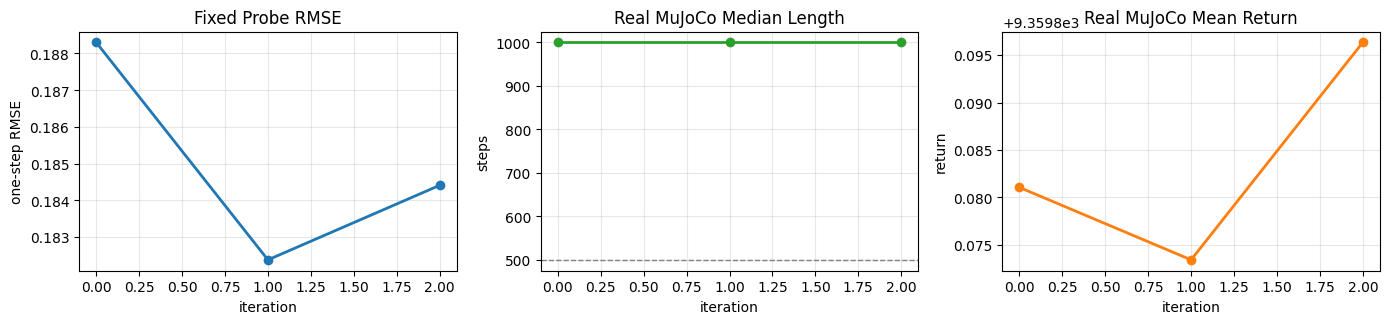

Iter 0: fixed RMSE=0.188303 | real median len=1000.0 | real mean return=9359.88
Iter 1: fixed RMSE=0.182380 | real median len=1000.0 | real mean return=9359.87
Iter 2: fixed RMSE=0.184410 | real median len=1000.0 | real mean return=9359.90

LQR verification criteria
  Target: real median episode length >= 500 steps
  Observed: 1000.0 steps
PASS: learned SINDy dynamics produce a controller that transfers to real MuJoCo.


In [15]:
iters = sorted(metrics_by_iter.keys())
fixed_rmse = [metrics_by_iter[i]["fixed_rmse"] for i in iters]
median_real_len = [real_eval_by_iter[i]["median_length"] for i in iters]
mean_real_return = [real_eval_by_iter[i]["mean_return"] for i in iters]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(iters, fixed_rmse, "o-", lw=2)
axes[0].set_title("Fixed Probe RMSE")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("one-step RMSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, median_real_len, "o-", lw=2, color="tab:green")
axes[1].axhline(500, color="gray", ls="--", lw=1)
axes[1].set_title("Real MuJoCo Median Length")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("steps")
axes[1].grid(True, alpha=0.3)

axes[2].plot(iters, mean_real_return, "o-", lw=2, color="tab:orange")
axes[2].set_title("Real MuJoCo Mean Return")
axes[2].set_xlabel("iteration")
axes[2].set_ylabel("return")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for i in iters:
    print(
        f"Iter {i}: fixed RMSE={metrics_by_iter[i]['fixed_rmse']:.6f} | "
        f"real median len={real_eval_by_iter[i]['median_length']:.1f} | "
        f"real mean return={real_eval_by_iter[i]['mean_return']:.2f}"
    )

if RUN_FINAL_LQR_ASSERT:
    print("\nLQR verification criteria")
    print("  Target: real median episode length >= 500 steps")
    print(f"  Observed: {final_lqr_eval['median_length']:.1f} steps")
    assert final_lqr_eval["median_length"] >= 500, (
        "SINDy-LQR did not transfer well enough. Check geometry, fixed validation RMSE, "
        "and the learned B matrix before trying PPO."
    )
    print("PASS: learned SINDy dynamics produce a controller that transfers to real MuJoCo.")
else:
    print("Final LQR assert skipped")


## 10. PPO After LQR Transfer

PPO is included here as a second-stage policy optimizer. It is trained in a guarded SINDy surrogate only after the learned model has passed the simpler LQR transfer check.

The guard matters: PPO can exploit unsupported corners of a learned model. The surrogate terminates when the predicted state leaves a conservative local support box or the tip falls.


In [16]:
def near_upright_initial_states(X, max_abs_angle=0.25, max_abs_velocity=3.0):
    """Choose PPO reset states close to the upright balancing region."""
    X = np.asarray(X, dtype=np.float64)
    mask = (
        (np.abs(X[:, 1]) <= max_abs_angle)
        & (np.abs(X[:, 2]) <= max_abs_angle)
        & (np.abs(X[:, 3]) <= max_abs_velocity)
        & (np.abs(X[:, 4]) <= max_abs_velocity)
        & (np.abs(X[:, 5]) <= max_abs_velocity)
    )
    selected = X[mask]
    if len(selected) == 0:
        print("No near-upright states found; falling back to the full dataset")
        return X
    print(f"PPO reset pool: {len(selected):,} near-upright states")
    return selected


class SINDySurrogateEnv(gym.Env):
    """Small Gymnasium wrapper around a learned SINDy model for PPO training."""
    metadata = {"render_modes": []}

    def __init__(self, sindy_model, initial_states, max_steps=PPO_SURROGATE_MAX_STEPS):
        super().__init__()
        self.sindy_model = sindy_model
        self.initial_states = np.asarray(initial_states, dtype=np.float64)
        self.max_steps = max_steps
        self.observation_space = spaces.Box(
            low=-SURROGATE_STATE_LIMITS.astype(np.float32),
            high=SURROGATE_STATE_LIMITS.astype(np.float32),
            shape=(STATE_DIM,),
            dtype=np.float32,
        )
        self.action_space = spaces.Box(ACTION_LOW, ACTION_HIGH, shape=(ACTION_DIM,), dtype=np.float32)
        self.state = None
        self.steps = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx = self.np_random.integers(0, len(self.initial_states))
        self.state = self.initial_states[idx].copy()
        self.state += self.np_random.normal(0.0, PPO_RESET_NOISE_STD, size=STATE_DIM)
        self.steps = 0
        return self.state.astype(np.float32), {}

    def step(self, action):
        action = np.asarray(action, dtype=np.float64).reshape(1)
        action = np.clip(action, ACTION_LOW, ACTION_HIGH)
        self.state = sindy_next(self.sindy_model, self.state, action[0])
        reward, tip_failed = reward_done_from_state6(self.state)

        outside_support = np.any(np.abs(self.state) > SURROGATE_STATE_LIMITS)
        invalid_state = not np.all(np.isfinite(self.state))
        terminated = bool(tip_failed or outside_support or invalid_state)
        if outside_support or invalid_state:
            reward -= 100.0

        self.steps += 1
        truncated = self.steps >= self.max_steps
        info = {
            "tip_height": tip_position_from_state6(self.state)[1] if not invalid_state else np.nan,
            "outside_support": bool(outside_support),
        }
        return self.state.astype(np.float32), float(reward), terminated, truncated, info


def train_ppo_in_surrogate(sindy_model, initial_states, total_timesteps=PPO_TOTAL_TIMESTEPS):
    """Train PPO in the guarded SINDy surrogate."""
    env = Monitor(SINDySurrogateEnv(sindy_model, initial_states))
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        ent_coef=0.01,
        verbose=0,
    )
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    model.save(str(PPO_MODEL_PATH))
    recent = env.get_episode_rewards()[-100:]
    if recent:
        print(f"PPO surrogate final-100 episode mean reward: {np.mean(recent):.2f}")
    print(f"Saved PPO model to {PPO_MODEL_PATH}")
    return model


In [17]:
def evaluate_real_ppo(ppo_model, n_episodes=N_EVAL_EPISODES, seed=50_000, label="PPO real eval"):
    """Evaluate a PPO policy trained on 6D SINDy states in real MuJoCo."""
    env = gym.make("InvertedDoublePendulum-v5")
    lengths, returns = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        ep_len = 0
        ep_ret = 0.0

        while not done:
            state = obs_to_state6(obs).astype(np.float32)
            action, _ = ppo_model.predict(state, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action.astype(np.float32))
            done = terminated or truncated
            ep_len += 1
            ep_ret += float(reward)

        lengths.append(ep_len)
        returns.append(ep_ret)

    env.close()
    return summarize_lengths_returns(lengths, returns, label)


ppo_model = None
ppo_real_eval = None

if RUN_PPO_AFTER_LQR:
    if final_lqr_eval["median_length"] < 500:
        print("Skipping PPO because the LQR transfer gate did not pass.")
    else:
        ppo_initial_states = near_upright_initial_states(X_all)
        ppo_model = train_ppo_in_surrogate(final_sindy_model, ppo_initial_states)
        ppo_real_eval = evaluate_real_ppo(ppo_model)
else:
    print("PPO stage skipped by RUN_PPO_AFTER_LQR=False")


PPO reset pool: 14,206 near-upright states
PPO surrogate final-100 episode mean reward: 189.28
Saved PPO model to /Users/patrick/Documents/personal/UW/ME_595/results/trackA_lqr_transfer/ppo_after_sindy_lqr
[PPO real eval] mean return 259.34 +/- 77.13
[PPO real eval] mean length 29.1 | median length 29.0
[PPO real eval] survive >500 steps 0% | reach time limit 0%
[PPO real eval] lengths: [32, 28, 30, 32, 46, 38, 15, 23, 24, 23]


## 11. Controller Rollout Visualization Utilities

These helpers mirror the plotting style from `notebooks/Exploratory/simulation.ipynb`, but they work with this notebook's controllers:

- `lqr`: real MuJoCo rollout using `u = -Kx`
- `ppo`: real MuJoCo rollout using the PPO policy trained on 6D SINDy states

The plots make failure modes visible: angle growth, cart drift, action saturation, reward collapse, and tip-height termination.


In [18]:
def rollout_real_controller(controller, kind, seed=0, max_steps=None, label=None):
    """Roll out one controller in real MuJoCo and record states/actions/rewards.

    Parameters
    ----------
    controller:
        LQR gain matrix for kind="lqr", or a Stable-Baselines3 PPO model for kind="ppo".
    kind:
        "lqr" or "ppo".
    seed:
        MuJoCo reset seed.
    max_steps:
        Optional early stop for plotting shorter windows.
    label:
        Optional label stored with the rollout.
    """
    env = gym.make("InvertedDoublePendulum-v5")
    obs, _ = env.reset(seed=seed)
    max_steps = env.spec.max_episode_steps if max_steps is None else max_steps

    states, actions, rewards, tip_heights = [], [], [], []
    done = False

    while not done and len(actions) < max_steps:
        state = obs_to_state6(obs)
        if kind == "lqr":
            action = action_from_lqr(controller, state)
        elif kind == "ppo":
            action, _ = controller.predict(state.astype(np.float32), deterministic=True)
            action = np.asarray(action, dtype=np.float32).reshape(1)
        else:
            raise ValueError(f"Unknown controller kind: {kind}")

        next_obs, reward, terminated, truncated, _ = env.step(action)
        states.append(state)
        actions.append(float(action[0]))
        rewards.append(float(reward))
        tip_heights.append(tip_position_from_state6(state)[1])
        obs = next_obs
        done = terminated or truncated

    env.close()
    states = np.asarray(states, dtype=np.float64)
    actions = np.asarray(actions, dtype=np.float64)
    rewards = np.asarray(rewards, dtype=np.float64)
    tip_heights = np.asarray(tip_heights, dtype=np.float64)
    time = np.arange(len(actions)) * DT
    status = "TASK COMPLETE" if len(actions) >= 1000 else "FAILED"

    rollout = {
        "label": label or kind.upper(),
        "kind": kind,
        "seed": seed,
        "time": time,
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "tip_heights": tip_heights,
        "length": int(len(actions)),
        "return": float(np.sum(rewards)),
        "status": status,
    }
    print(
        f"[{rollout['label']}] {rollout['length']} steps | "
        f"return {rollout['return']:.2f} | {status}"
    )
    return rollout


def plot_controller_rollout(rollout):
    """Plot one rollout's state, action, reward, and tip-height traces."""
    states = rollout["states"]
    time = rollout["time"]
    actions = rollout["actions"]
    rewards = rollout["rewards"]
    tip_heights = rollout["tip_heights"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    (ax_x, ax_th, ax_act), (ax_xd, ax_thd, ax_rew) = axes

    ax_x.plot(time, states[:, 0], color="steelblue", lw=1.2, label="x_cart")
    ax_x.axhline(0, color="gray", ls="--", lw=1)
    ax_x.set_xlabel("Time (s)")
    ax_x.set_ylabel("Position (m)")
    ax_x.set_title("Cart position")
    ax_x.legend(fontsize=8)

    ax_th.plot(time, np.degrees(states[:, 1]), color="darkorange", lw=1.2, label="theta1")
    ax_th.plot(time, np.degrees(states[:, 2]), color="mediumpurple", lw=1.2, label="theta2")
    ax_th.axhline(0, color="gray", ls="--", lw=1)
    ax_th.set_xlabel("Time (s)")
    ax_th.set_ylabel("Angle (deg)")
    ax_th.set_title("Pole angles")
    ax_th.legend(fontsize=8)

    ax_act.plot(time, actions, color="teal", lw=1.0)
    ax_act.axhline(1, color="gray", ls=":", lw=1)
    ax_act.axhline(-1, color="gray", ls=":", lw=1)
    ax_act.set_xlabel("Time (s)")
    ax_act.set_ylabel("Action")
    ax_act.set_title("Cart force action")

    ax_xd.plot(time, states[:, 3], color="steelblue", lw=1.0)
    ax_xd.axhline(0, color="gray", ls="--", lw=1)
    ax_xd.set_xlabel("Time (s)")
    ax_xd.set_ylabel("Velocity (m/s)")
    ax_xd.set_title("Cart velocity")

    ax_thd.plot(time, states[:, 4], color="darkorange", lw=1.0, label="theta1dot")
    ax_thd.plot(time, states[:, 5], color="mediumpurple", lw=1.0, label="theta2dot")
    ax_thd.axhline(0, color="gray", ls="--", lw=1)
    ax_thd.set_xlabel("Time (s)")
    ax_thd.set_ylabel("Angular velocity (rad/s)")
    ax_thd.set_title("Pole angular velocities")
    ax_thd.legend(fontsize=8)

    ax_rew.plot(time, rewards, color="coral", lw=1.0, label="reward")
    ax_rew_twin = ax_rew.twinx()
    ax_rew_twin.plot(time, tip_heights, color="forestgreen", lw=1.0, alpha=0.75, label="tip_height")
    ax_rew.axhline(np.mean(rewards), color="red", ls="--", lw=1.2)
    ax_rew_twin.axhline(TIP_HEIGHT_FALL_THRESHOLD, color="black", ls=":", lw=1)
    ax_rew.set_xlabel("Time (s)")
    ax_rew.set_ylabel("Step reward")
    ax_rew_twin.set_ylabel("Tip height")
    ax_rew.set_title("Reward and tip height")

    title_color = "darkgreen" if rollout["status"] == "TASK COMPLETE" else "red"
    plt.suptitle(
        f"{rollout['label']} real MuJoCo rollout - "
        f"{rollout['length']} steps, return {rollout['return']:.1f} ({rollout['status']})",
        fontsize=11,
        fontweight="bold",
        color=title_color,
    )
    plt.tight_layout()
    plt.show()


def plot_controller_comparison(rollouts):
    """Overlay key traces for multiple controller rollouts."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    (ax_len, ax_angle), (ax_action, ax_reward) = axes

    for rollout in rollouts:
        label = rollout["label"]
        t = rollout["time"]
        states = rollout["states"]
        angle_norm = np.degrees(np.sqrt(states[:, 1] ** 2 + states[:, 2] ** 2))
        cumulative_reward = np.cumsum(rollout["rewards"])

        ax_len.plot(t, rollout["tip_heights"], lw=1.4, label=label)
        ax_angle.plot(t, angle_norm, lw=1.4, label=label)
        ax_action.plot(t, rollout["actions"], lw=1.0, label=label)
        ax_reward.plot(t, cumulative_reward, lw=1.4, label=label)

    ax_len.axhline(TIP_HEIGHT_FALL_THRESHOLD, color="black", ls=":", lw=1, label="fall threshold")
    ax_len.set_title("Tip height")
    ax_len.set_xlabel("Time (s)")
    ax_len.set_ylabel("Height")
    ax_len.legend(fontsize=8)

    ax_angle.set_title("Angle error magnitude")
    ax_angle.set_xlabel("Time (s)")
    ax_angle.set_ylabel("Degrees")
    ax_angle.legend(fontsize=8)

    ax_action.axhline(1, color="gray", ls=":", lw=1)
    ax_action.axhline(-1, color="gray", ls=":", lw=1)
    ax_action.set_title("Action")
    ax_action.set_xlabel("Time (s)")
    ax_action.set_ylabel("Normalized force")
    ax_action.legend(fontsize=8)

    ax_reward.set_title("Cumulative reward")
    ax_reward.set_xlabel("Time (s)")
    ax_reward.set_ylabel("Return so far")
    ax_reward.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


[SINDy-LQR] 1000 steps | return 9359.81 | TASK COMPLETE


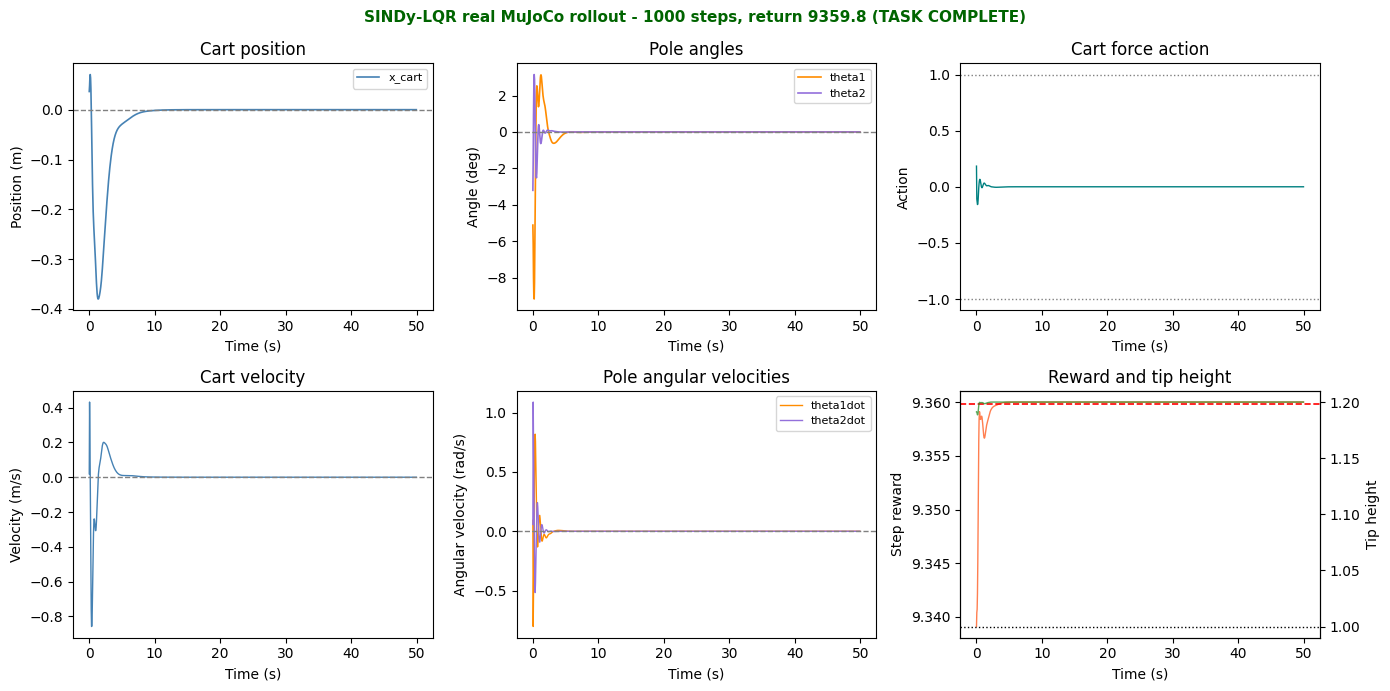

[PPO-on-SINDy] 26 steps | return 229.26 | FAILED


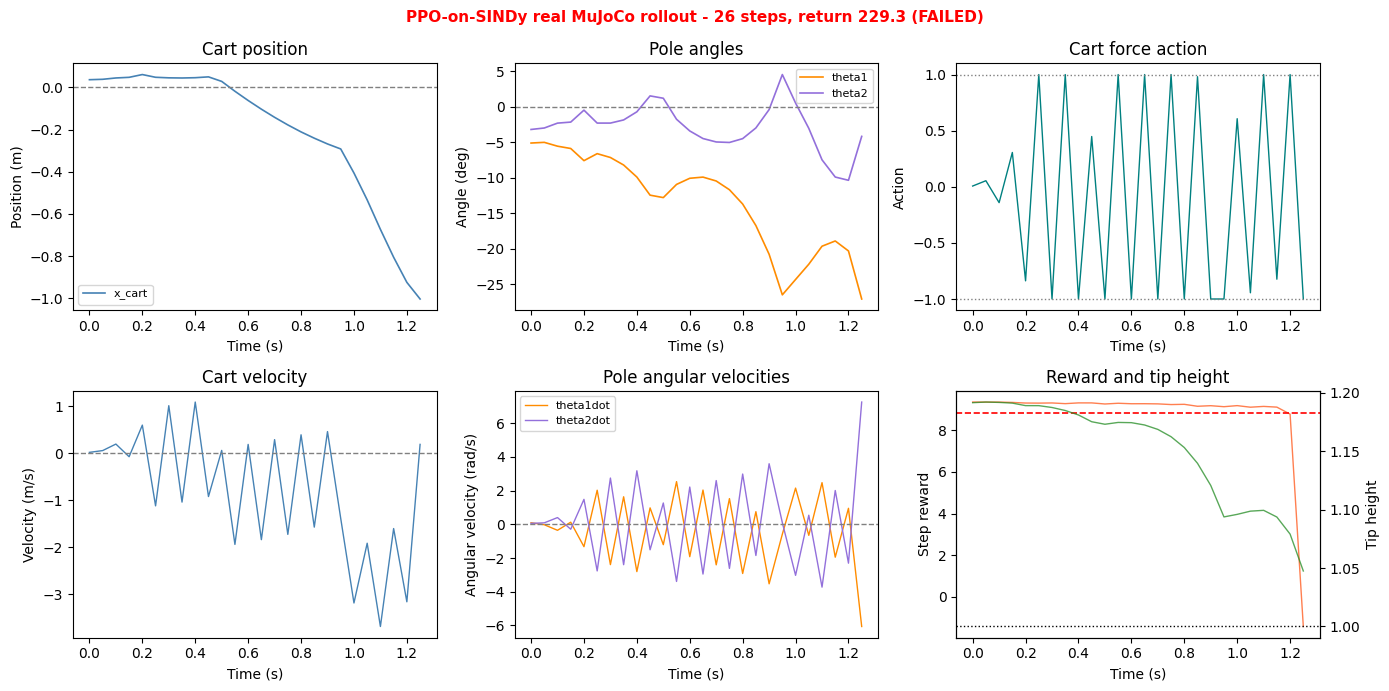

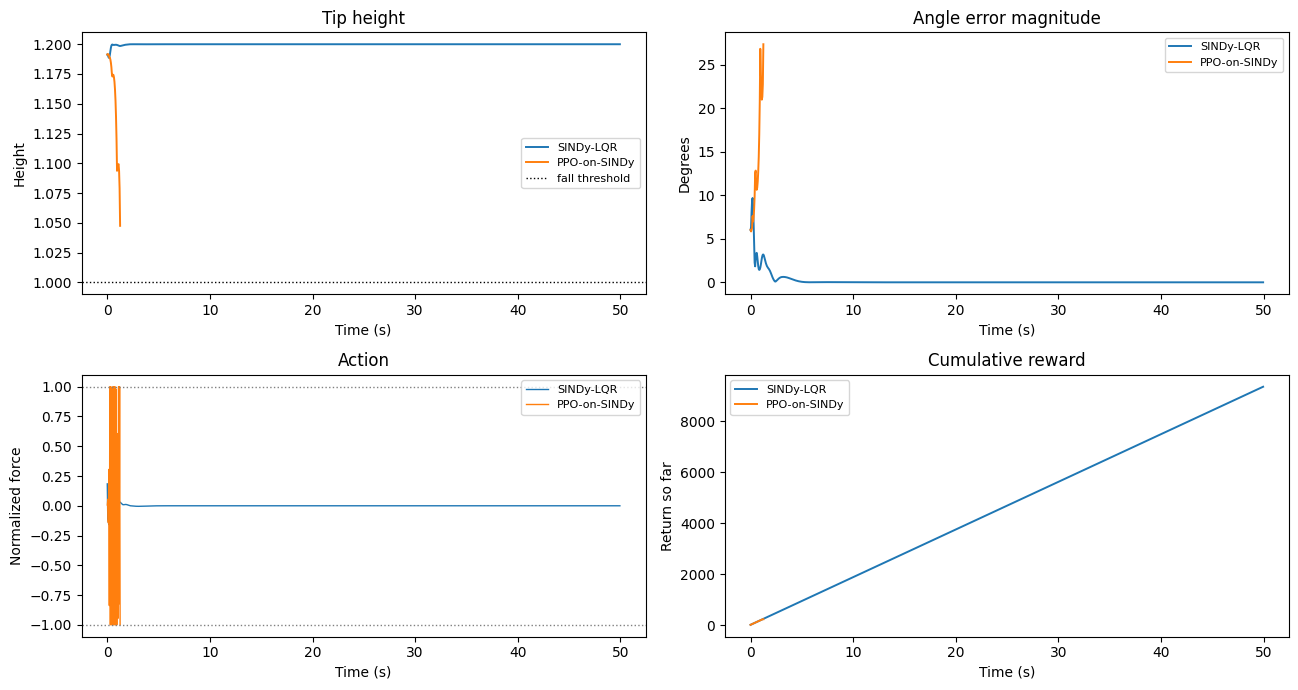

In [19]:
# Example visualizations. Run this after the LQR and optional PPO sections above.
lqr_rollout = rollout_real_controller(final_lqr_gain, kind="lqr", seed=123, label="SINDy-LQR")
plot_controller_rollout(lqr_rollout)

comparison_rollouts = [lqr_rollout]
if ppo_model is not None:
    ppo_rollout = rollout_real_controller(ppo_model, kind="ppo", seed=123, label="PPO-on-SINDy")
    plot_controller_rollout(ppo_rollout)
    comparison_rollouts.append(ppo_rollout)
else:
    print("PPO model is None; run the PPO section first to compare PPO-on-SINDy.")

plot_controller_comparison(comparison_rollouts)


## 12. Optional Rendered Animation

This uses MuJoCo's `rgb_array` renderer. It is useful for presentation, but the trajectory plots above are usually better for debugging.


In [20]:
def animate_real_controller(controller, kind, seed=0, frame_stride=4, label="controller"):
    """Render one real MuJoCo episode as a notebook animation."""
    import matplotlib.animation as animation
    from IPython.display import HTML

    env = gym.make("InvertedDoublePendulum-v5", render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    done = False

    while not done:
        state = obs_to_state6(obs)
        if kind == "lqr":
            action = action_from_lqr(controller, state)
        elif kind == "ppo":
            action, _ = controller.predict(state.astype(np.float32), deterministic=True)
            action = np.asarray(action, dtype=np.float32).reshape(1)
        else:
            raise ValueError(f"Unknown controller kind: {kind}")
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frames.append(env.render())

    env.close()
    n_steps = len(frames) - 1
    status = "TASK COMPLETE" if n_steps >= 1000 else "FAILED"
    print(f"[{label}] rendered {n_steps} steps ({status})")

    fig, ax = plt.subplots(figsize=(4, 6))
    ax.axis("off")
    ax.set_title(f"{label}: {n_steps} steps ({status})", fontsize=9)
    image = ax.imshow(frames[0])

    def _update(i):
        image.set_data(frames[i])
        return [image]

    anim = animation.FuncAnimation(
        fig,
        _update,
        frames=range(0, len(frames), frame_stride),
        interval=50,
        blit=True,
    )
    plt.close(fig)
    return HTML(anim.to_jshtml())


# Uncomment one of these when you want a rendered movie.
# animate_real_controller(final_lqr_gain, kind="lqr", seed=123, label="SINDy-LQR")
animate_real_controller(ppo_model, kind="ppo", seed=123, label="PPO-on-SINDy")


[PPO-on-SINDy] rendered 26 steps (FAILED)


## 13. Final Interpretation

Use this order when deciding what to trust:

1. Geometry check catches reward/termination mistakes.
2. Fixed validation RMSE shows one-step model quality on the same probe set each time.
3. Real SINDy-LQR evaluation shows whether the learned local dynamics can produce a real controller.
4. PPO is only useful if it improves real MuJoCo behavior, not just surrogate reward.

If PPO does worse than LQR in real MuJoCo, keep the LQR result as the validated controller and treat PPO as an over-optimization problem to debug separately.
